# Applying the Multinomial Naïve Bayes Algorithm to Build an SMS Spam Filter

# Aim

This project sets out to build a spam filter for Short Message Service (SMS) messages, utilising the multinomial Naïve Bayes algorithm. The goal is to write a program that is able to classify new messages with an accuracy greater than 80%.

To train the algorithm, a dataset containing 5,572 SMS messages that have been classified as `spam` or `ham` (non-spam) is to be used. 

This dataset was gathered by Tiago A. Almeida and José María Gómez Hidalgo and is publically available for download from the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/228/sms+spam+collection). For further details on the dataset, refer to the `readme` file in the workspace.

>*Note,* due to the nature of text messaging and spam, the content of some messages may be offensive to some users.

# Exploring the Dataset

In [1]:
import pandas as pd
pd.options.display.max_colwidth = None

data = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["Label", "Message"])

data.head(10)

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
5,spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv"
6,ham,Even my brother is not like to speak with me. They treat me like aids patent.
7,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
8,spam,WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
9,spam,Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Label    5572 non-null   str  
 1   Message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


The training data contains no null values, an essential condition to train the algorithm.

In [3]:
data['Label'].value_counts(normalize=True, ascending=False)*100

Label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

The training data is comprised of ~86.6% ham and ~13.4% spam messages. This looks to be a relatively representative sample from everyday experience - in practice, most SMS messages received are ham.

# Training and Test Dataset

In order to test the accuracy of the classifier, unbiased test cases must be fed to the program and compared against a human evaluated response for each test case. We can prepare for testing by splitting the original dataset into a training and testing set.

We will use an 80/20 split - 80% of the data will be used to train the classifier, leaving the remaining 20% for testing. The majority of the data is used for training since model accuracy generally improves with larger training sets. 

To ensure the training and testing datasets will both have proportions of spam and ham messages that resemble the original full dataset: 

* Randomize the full dataset
* 80/20 split the dataset on the index

In [4]:
randomized_data = data.sample(frac=1, random_state=1).reset_index(drop=True) # frac=1 to return all rows in random order. random_state is set for reproducibility

randomized_data.head(10)

,Label,Message
0,ham,"Yep, by the pretty sculpture"
1,ham,"Yes, princess. Are you going to make me moan?"
2,ham,Welp apparently he retired
3,ham,Havent.
4,ham,I forgot 2 ask ü all smth.. There's a card on da present lei... How? Ü all want 2 write smth or sign on it?
5,ham,Ok i thk i got it. Then u wan me 2 come now or wat?
6,ham,I want kfc its Tuesday. Only buy 2 meals ONLY 2. No gravy. Only 2 Mark. 2!
7,ham,No dear i was sleeping :-P
8,ham,Ok pa. Nothing problem:-)
9,ham,Ill be there on &lt;#&gt; ok.


Original dataset is randomized.

In [5]:
training_data_index = round(len(randomized_data)*0.8)
training_data = randomized_data[:training_data_index].reset_index(drop=True)
testing_data = randomized_data[training_data_index:].reset_index(drop=True)

print(f"Training data size: {len(training_data)}")
print(f"Testing data size: {len(testing_data)}")

Training data size: 4458
Testing data size: 1114


The 80/20 split has been performed.

In [6]:
training_data.head()

,Label,Message
0,ham,"Yep, by the pretty sculpture"
1,ham,"Yes, princess. Are you going to make me moan?"
2,ham,Welp apparently he retired
3,ham,Havent.
4,ham,I forgot 2 ask ü all smth.. There's a card on da present lei... How? Ü all want 2 write smth or sign on it?


In [7]:
testing_data.head()

,Label,Message
0,ham,Later i guess. I needa do mcat study too.
1,ham,But i haf enuff space got like 4 mb...
2,spam,Had your mobile 10 mths? Update to latest Orange camera/video phones for FREE. Save £s with Free texts/weekend calls. Text YES for a callback orno to opt out
3,ham,All sounds good. Fingers . Makes it difficult to type
4,ham,"All done, all handed in. Don't know if mega shop in asda counts as celebration but thats what i'm doing!"


In [8]:
print(f"""Training: 
{training_data['Label'].value_counts(normalize=True)*100}
""")

print(f"""Testing: 
{testing_data['Label'].value_counts(normalize=True)*100}
""")

Training: 
Label
ham     86.54105
spam    13.45895
Name: proportion, dtype: float64

Testing: 
Label
ham     86.804309
spam    13.195691
Name: proportion, dtype: float64



We verify that the training and testing datasets have proportions of spam and ham messages that closely resemble the original dataset. The results are good, so we can move forward to preparing the data.

# Preparing the Training Dataset

To implement the algorithm, the message data must be transformed into a form that enables information to be easily extracted from it:

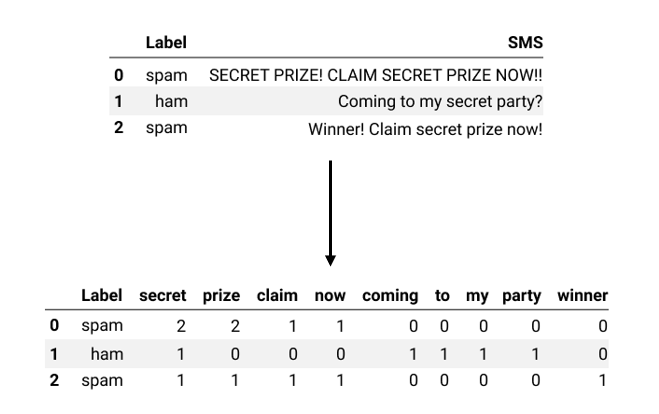

The process is begun by stripping all punctuation from the messages and converting all letter characters to lowercase.

In [9]:
training_data["Message"] = training_data["Message"].str.replace(r"\W", " ", regex=True).str.lower().str.split().str.join(" ") # remove all punctuation, convert to lowercase, and remove extra spaces

training_data.head(10)

,Label,Message
0,ham,yep by the pretty sculpture
1,ham,yes princess are you going to make me moan
2,ham,welp apparently he retired
3,ham,havent
4,ham,i forgot 2 ask ü all smth there s a card on da present lei how ü all want 2 write smth or sign on it
5,ham,ok i thk i got it then u wan me 2 come now or wat
6,ham,i want kfc its tuesday only buy 2 meals only 2 no gravy only 2 mark 2
7,ham,no dear i was sleeping p
8,ham,ok pa nothing problem
9,ham,ill be there on lt gt ok


Then, the **vocabulary** of the dataset must be found - every unique word present in the dataset (a word is defined here as a series of characters initiated and terminated by whitespace).

In [10]:
training_vocabulary = []

for message in training_data["Message"]:
    for word in message.split():
        if word not in training_vocabulary:
            training_vocabulary.append(word)
            
print(f"Size of training vocabulary: {len(training_vocabulary):,}")
print(f"First 20 words in training vocabulary: {training_vocabulary[:20]}")

Size of training vocabulary: 7,783
First 20 words in training vocabulary: ['yep', 'by', 'the', 'pretty', 'sculpture', 'yes', 'princess', 'are', 'you', 'going', 'to', 'make', 'me', 'moan', 'welp', 'apparently', 'he', 'retired', 'havent', 'i']


We now create a dictionary to store the word counts per message. The vocabulary found above is used such that the count of every word in the vocabulary is included for each SMS message.

Iterating over each message and each word within each message, we increment the count by one for every appearance of that word. The result is the **feature matrix** below:

In [11]:
word_counts_per_message = {unique_word: [0] * len(training_data["Message"]) for unique_word in training_vocabulary} # initialize dictionary with each unique word as key and a list of zeros as value

for index, message in enumerate(training_data["Message"]): 
    for word in message.split():
        word_counts_per_message[word][index] += 1  # increment the count for each word in the corresponding message

word_counts_per_message = pd.DataFrame(word_counts_per_message) # convert the dictionary to a DataFrame

word_counts_per_message.head()

,yep,by,the,pretty,sculpture,yes,princess,are,you,going,...,beauty,hides,secrets,n8,jewelry,related,trade,arul,bx526,wherre
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The feature matrix can now be concatenated with the training_data dataframe to produce the finalized training dataset.

In [12]:
training_data = pd.concat([training_data, word_counts_per_message], axis=1)

training_data.head()

,Label,Message,yep,by,the,pretty,sculpture,yes,princess,are,...,beauty,hides,secrets,n8,jewelry,related,trade,arul,bx526,wherre
0,ham,yep by the pretty sculpture,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ham,yes princess are you going to make me moan,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ham,welp apparently he retired,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ham,havent,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ham,i forgot 2 ask ü all smth there s a card on da present lei how ü all want 2 write smth or sign on it,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Explanation of the Algorithm

A Naïve Bayes Classifier is part of a family of generative learning algorithms that predicts the category of a data point using Bayes’ Theorem (conditional probability theory). Here, the **multinomial** Bayes classifier will be implemented as we are handling discrete data.

For the algorithm to classify a new message as spam or ham, the following probabilities must be determined:

1.   $P(Spam│Message)=  \frac{P(Spam)∙P(Message│Spam)}{P(Message)}$ : the probability the message is spam given the message has been received
---
2.   $P(Ham│Message)=  \frac{P(Ham)∙P(Message│Ham)}{P(Message)}$ : the probability the message is ham given the message has been received

If equation 1 > equation 2, the new message will be classified as a spam message. Otherwise, it will be considered ham.

Since $P(Message)$ appears in both equations above, we can omit these terms since we are simply comparing the result of the two calculations. This reduces the number of operations required for the classifier to come to a conclusions, improving the performance of the classifier.

The two equations can now be represented as:

1. $P(Spam│Message) ∝ P(Spam)∙P(Message│Spam)$
---
2. $P(Ham│Message) ∝ P(Ham)∙P(Message│Ham)$

The `Message` event in the formulae above is actually a composite event. 

Consider a four-word message "hi how are you". $P(Message)$ is equivalent to $P("hi"∩"how"∩"are"∩"you")$.

From equation 1, the required value becomes $P(Spam│"hi"∩"how"∩"are"∩"you")$. This is directly proportional to $P(Spam ∩"hi"∩"how"∩"are"∩"you")$ which can be expanded with the **multiplication rule** to:
$$
P(Spam ∩"hi"∩"how"∩"are"∩"you") = P("hi"|"how"∩"are"∩"you"∩ Spam)∙P("how"|"are"∩"you"∩ Spam)∙P("are"|"you"∩ Spam)
$$

Here, we can further simply the computation by assuming **conditional independence** - this is what makes the algorithm **naïve**. This simplifies the above equation to:

$$
P(Spam│"hi"∩"how"∩"are"∩"you") ∝ P(Spam ∩"hi"∩"how"∩"are"∩"you") = P("hi"|Spam)∙P("how"|Spam)∙P("are"|Spam)∙P("you"|Spam)
$$

### The General Formula for the Bayes Algorithm

$P(A│B_1,B_2,…,B_n )∝P(A)∙P(B_1│A)∙P(B_2│A)∙…∙P(B_n│A)$

which is written:

$P(A│B_1,B_2,…,B_n )∝P(A)∙\displaystyle\prod_{i=1}^n P(B_i│A)$ 

Therefore, spam filter classifier must calculate the following probabilities:

>1. $P(Spam│word_1,word_2,…,word_n )∝P(Spam)∙\displaystyle\prod_{i=1}^n P(word_i│Spam)$ 
>
>2. $P(Ham│word_1,word_2,…,word_n )∝P(Ham)∙\displaystyle\prod_{i=1}^n P(word_i│Ham)$ 

where event A is whether the message is Spam (or Ham) and event $B_i$ is $word_i$ appearing in the message.

If equation 1 > equation 2, the classifier will return spam, otherwise ham.

## Additional Consideration: Smoothing

We must consider the scenario where unseen messages contain words that are *not* in the training dataset vocabulary. 

In these cases, one or more of the $P(word_i|Spam)$ and $P(word_i|Ham)$ terms will evaulate to **0**. This is a problem as it will cause the result of the entire calculation to evaluate to zero. To avoid this, we can ignore $P(word_i|Spam)$ for words that do not appear in the training dataset vocabulary. We can do so since this will not affect the result of the comparison between the two results from equation 1 and 2 (since they are treated in the same way). 

Additionally, in cases where a message contains words that belong to *only* spam or ham, one of $P(word_i|Spam)$ and $P(word_i|Ham)$ evaluate to zero. To avoid this, a smoothing parameter ($\alpha$) must be introduced into the calculations (to avoid terms evaluating to zero).

This transforms the $P(word_i│Spam)$ and $P(word_i│Ham)$ components of the calculation to the following:

$$
P(word_i│Spam) = \frac{N_{word_i|Spam} + \alpha}{N_{Spam} + \alpha∙N_{Vocabulary}}
$$

$$
P(word_i│Ham) = \frac{N_{word_i|Ham} + \alpha}{N_{Ham} + \alpha∙N_{Vocabulary}}
$$

where $N_{Spam}$, $N_{Ham}$ are the number of words in all spam and ham messages respectively and $N_{Vocabulary}$ is the total number of words in the vocabulary.

We are now prepared to program the algorithm.

## Coding the Algorithm

### Calculating Constants

Some terms in equations 1 and 2 above are constant:

* $P(Spam)$ 
* $P(Ham)$
* $N_{Spam}$, $N_{Ham}$ and $N_{Vocabulary}$

The value of the smoothing factor, $\alpha$, is also treated as a constant. When it takes on the value of 1 - this is known as the **Laplace Smoothing Factor** which is the most straight-forward value it can take. 

In [13]:
alpha = 1  # Laplace smoothing factor

training_data_spam = training_data[training_data["Label"] == "spam"]
training_data_ham = training_data[training_data["Label"] == "ham"]

# P(Spam) and P(Ham)
p_spam = len(training_data_spam) / len(training_data)
p_ham = len(training_data_ham) / len(training_data)

# N_vocab
n_vocab = len(training_vocabulary)

# N_spam and N_ham
n_spam = training_data_spam.iloc[:, 2:].sum().sum()  # sum of all word counts in spam messages
n_ham = training_data_ham.iloc[:, 2:].sum().sum()    # sum of all word counts in ham messages

print(f"""P(Spam): {p_spam:.4f}
P(Ham): {p_ham:.4f}
N_vocab: {n_vocab:,}
N_spam: {n_spam:,}
N_ham: {n_ham:,}
""")

P(Spam): 0.1346
P(Ham): 0.8654
N_vocab: 7,783
N_spam: 15,190
N_ham: 57,237



## Calculating Parameters

After calculation of the constants above, we move to calculate the parameters $P(w_{i}|Spam)$ and $P(w_{i}|Ham)$. Each value is a conditional probability value associated with each word in the vocabulary. 

Once calculated for a word, it does not need to be calculated again. Due to this, we can save the values for each word as a dictionary.

The parameters are calculated using the equations:

$$
P(word_i│Spam) = \frac{N_{word_i|Spam} + \alpha}{N_{Spam} + \alpha∙N_{Vocabulary}}
$$

$$
P(word_i│Ham) = \frac{N_{word_i|Ham} + \alpha}{N_{Ham} + \alpha∙N_{Vocabulary}}
$$

In [14]:
p_word_given_spam = {unique_word: 0 for unique_word in training_vocabulary} # initialize dictionary to hold P(word|Spam) parameters

p_word_given_ham = {unique_word: 0 for unique_word in training_vocabulary} # initialize dictionary to hold P(word|Ham) parameters

for word in training_vocabulary:
    n_word_given_spam = training_data_spam[word].sum() # number of times the word appears in spam messages
    n_word_given_ham = training_data_ham[word].sum() # number of times the word appears in ham messages
    
    p_word_given_spam[word] = (n_word_given_spam + alpha) / (n_spam + alpha * n_vocab) # calculate P(word|Spam) with Laplace smoothing, storing in dictionary
    p_word_given_ham[word] = (n_word_given_ham + alpha) / (n_ham + alpha * n_vocab) # calculate P(word|Ham) with Laplace smoothing, storing in dictionary
    
print(f"""P(word|Spam) for first 3 words:
{ {word: p_word_given_spam[word] for word in training_vocabulary[:3]} }

P(word|Ham) for first 3 words:
{ {word: p_word_given_ham[word] for word in training_vocabulary[:3]} }
""")

P(word|Spam) for first 3 words:
{'yep': np.float64(4.3529360553693465e-05), 'by': np.float64(0.0015235276193792714), 'the': np.float64(0.006877638967483567)}

P(word|Ham) for first 3 words:
{'yep': np.float64(0.00015379883112888343), 'by': np.float64(0.001707167025530606), 'the': np.float64(0.014164872346970163)}



## Creating the Spam Filter

Now that the constants and parameters have been calculated, the spam filter can be created. This will be a function that:

* Takes a message as an input (containing words: $w_{1}$, $w_{2}$, ... , $w_{n}$)
* Calculates the relevant probabilities $P(Spam|w_{1}, w_{2}, ... , w_{n})$ and $P(Ham|w_{1}, w_{2}, ..., w_{n})$
* Compares the probability values, classifying a message as:

  - Ham if $P(Spam|w_{1}, w_{2}, ... , w_{n})$ < $P(Ham|w_{1}, w_{2}, ... , w_{n})$
  - Spam if $P(Spam|w_{1}, w_{2}, ... , w_{n})$ > $P(Ham|w_{1}, w_{2}, ... , w_{n})$
  - Undetermined if $P(Spam|w_{1}, w_{2}, ... , w_{n})$ = $P(Ham|w_{1}, w_{2}, ... , w_{n})$

In [15]:
import re

def classify(message):
  # Preprocess message - remove non-word characters, convert to lowercase, split into words
  message = re.sub(r"\W", " ", message).lower().split()
  
  p_spam_given_message = p_spam # initialize P(Spam|message) with P(Spam)
  p_ham_given_message = p_ham # initialize P(Ham|message) with P(Ham)
  
  for word in message:
    if word in training_vocabulary:                    # only consider words in the training vocabulary
      p_spam_given_message *= p_word_given_spam[word]  # multiply P(Spam) by P(word|Spam) for each word in the message
      p_ham_given_message *= p_word_given_ham[word]    # multiply P(Ham) by P(word|Ham) for each word in the message
  
  print('P(Spam|message):', p_spam_given_message)
  print('P(Ham|message):', p_ham_given_message)
  
  if p_ham_given_message > p_spam_given_message:
    print('Result: Ham')
  
  elif p_ham_given_message < p_spam_given_message:
    print('Result: Spam')
    
  else:
    print('Result: Undetermined, human review needed')

In [16]:
classify("Congratulations! You've won a $1,000 Walmart gift card. Go to http://bit.ly/12345 to claim now.")

P(Spam|message): 1.4224451168082718e-49
P(Ham|message): 1.3000029408270015e-56
Result: Spam


In [17]:
classify("hey bby, how r u doin? :)")

P(Spam|message): 2.1055070542490482e-18
P(Ham|message): 1.8402972960483894e-14
Result: Ham


## Measuring the Accuracy of the Classifier

The classifier is used to predict whether the messages in the testing dataset are spam or ham. The accuracy of the classifier can then be determined by calculating the number of correct predictions over the total number of messages in the test dataset.

In [18]:
def classify(message):
  # Preprocess message
  message = re.sub(r"\W", " ", message).lower().split()
  
  p_spam_given_message = p_spam
  p_ham_given_message = p_ham
  
  for word in message:
    if word in training_vocabulary:
      p_spam_given_message *= p_word_given_spam[word]
      p_ham_given_message *= p_word_given_ham[word]
  
  if p_ham_given_message > p_spam_given_message:
    return "ham"
  
  elif p_ham_given_message < p_spam_given_message:
    return "spam"
  
  else:
    return "undetermined"

In [19]:
testing_data["Prediction"] = testing_data["Message"].apply(classify)

In [20]:
testing_data.head(10)

,Label,Message,Prediction
0,ham,Later i guess. I needa do mcat study too.,ham
1,ham,But i haf enuff space got like 4 mb...,ham
2,spam,Had your mobile 10 mths? Update to latest Orange camera/video phones for FREE. Save £s with Free texts/weekend calls. Text YES for a callback orno to opt out,spam
3,ham,All sounds good. Fingers . Makes it difficult to type,ham
4,ham,"All done, all handed in. Don't know if mega shop in asda counts as celebration but thats what i'm doing!",ham
5,ham,But my family not responding for anything. Now am in room not went to home for diwali but no one called me and why not coming. It makes me feel like died.,ham
6,ham,U too...,ham
7,ham,Boo what time u get out? U were supposed to take me shopping today. :(,ham
8,ham,Genius what's up. How your brother. Pls send his number to my skype.,ham
9,ham,I liked the new mobile,ham


In [21]:
correct = 0
total = len(testing_data)

for index, row in testing_data.iterrows():
    if row["Label"] == row["Prediction"]:
        correct += 1

incorrect = total - correct
accuracy = correct / total

print(f"""Correct: {correct:,}
Incorrect: {incorrect:,}
Total: {total:,}
Accuracy: {accuracy:.2%}""")

Correct: 1,100
Incorrect: 14
Total: 1,114
Accuracy: 98.74%


#### Misclassified Messages

In [22]:
rows = []

for index, row in testing_data.iterrows():
    if row["Label"] != row["Prediction"]:
        rows.append(row)
        

misclassified = pd.DataFrame(rows)      
misclassified

,Label,Message,Prediction
114,spam,Not heard from U4 a while. Call me now am here all night with just my knickers on. Make me beg for it like U did last time 01223585236 XX Luv Nikiyu4.net,ham
135,spam,More people are dogging in your area now. Call 09090204448 and join like minded guys. Why not arrange 1 yourself. There's 1 this evening. A£1.50 minAPN LS278BB,ham
152,ham,Unlimited texts. Limited minutes.,spam
159,ham,26th OF JULY,spam
284,ham,Nokia phone is lovly..,spam
293,ham,"A Boy loved a gal. He propsd bt she didnt mind. He gv lv lttrs, Bt her frnds threw thm. Again d boy decided 2 aproach d gal , dt time a truck was speeding towards d gal. Wn it was about 2 hit d girl,d boy ran like hell n saved her. She asked 'hw cn u run so fast?' D boy replied ""Boost is d secret of my energy"" n instantly d girl shouted ""our energy"" n Thy lived happily 2gthr drinking boost evrydy Moral of d story:- I hv free msgs:D;): gud ni8",undetermined
302,ham,No calls..messages..missed calls,spam
319,ham,"We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us",spam
504,spam,"Oh my god! I've found your number again! I'm so glad, text me back xafter this msgs cst std ntwk chg £1.50",ham
546,spam,"Hi babe its Chloe, how r u? I was smashed on saturday night, it was great! How was your weekend? U been missing me? SP visionsms.com Text stop to stop 150p/text",ham


## Discussion of Results

The classifier has achieved an accuracy of 98.74%, misclassifying only 14 messages. This is a great result!

Looking more closely at the misclassified messages, some are clearly misclassified (such as row_index 114, 135, 504). 

There are however some messages which are near or on the borderline. The message with row index 293 for instance is the only message that received an undetermined prediction. Looking at the content of the message from a human perspective, it does not seem like a typical message you would receive. It is understandable that messages of this nature will be misclassified.

We cannot expect 100% accuracy since at the end of the day, we are relying on probability theory. The Naïve Bayes algorithm also heavily depends on the assumption of *conditional independence*.This assumption is certainly not 100% valid when dealing with words since the probability that a word appears in a message will likely be dependent on whether another word is also in the message. For instance, the word "night" will depend on "good" (*i.e.,* if "good" appears in a message, the probability that "night" is also present in the message will increase). 

Nevertheless, an accuracy of 98.74% is significantly greater than the initial goal of 80% as outlined in the introduction. There is indeed merit in using the program as a spam-filter.

## Trialling Lidstone Smoothing

Finally, we can attempt to optimize the classifier by adjusting the smoothing parameter $\alpha$. When $\alpha$ takes a value between 0 and 1, this is commonly referred to as **Lidstone Smoothing**.

This is preferable over the more simplistic **Laplace Smoothing** due to the flexibility of the smoothing parameter which can lead to an improvement in classifier accuracy. It can however be time consuming to find the best value of $\alpha$ for a given application.

>Through simple trial and error, $\alpha$ = 0.7 has shown to be *slightly* better for model accuracy, reducing the number of misclassified messages from 14 to 13 (with a new accuracy of 98.83%). Based on this limited experimentation, it does not seem likely that the accuracy can be further raised by any meaningful amount.

In [ ]:
alpha = 0.7 # Adjusted smoothing factor

p_word_given_spam_lid = {unique_word: 0 for unique_word in training_vocabulary} # initialize dictionary to hold P(word|Spam) parameters

p_word_given_ham_lid = {unique_word: 0 for unique_word in training_vocabulary} # initialize dictionary to hold P(word|Ham) parameters

for word in training_vocabulary:
    n_word_given_spam = training_data_spam[word].sum() # number of times the word appears in spam messages
    n_word_given_ham = training_data_ham[word].sum() # number of times the word appears in ham messages
    
    p_word_given_spam_lid[word] = (n_word_given_spam + alpha) / (n_spam + alpha * n_vocab) # calculate P(word|Spam) with Laplace smoothing, storing in dictionary
    p_word_given_ham_lid[word] = (n_word_given_ham + alpha) / (n_ham + alpha * n_vocab) # calculate P(word|Ham) with Laplace smoothing, storing in dictionary
    
print(f"""P(word|Spam) for first 3 words:
{ {word: p_word_given_spam[word] for word in training_vocabulary[:3]} }

P(word|Ham) for first 3 words:
{ {word: p_word_given_ham[word] for word in training_vocabulary[:3]} }
""")

P(word|Spam) for first 3 words:
{'yep': np.float64(4.3529360553693465e-05), 'by': np.float64(0.0015235276193792714), 'the': np.float64(0.006877638967483567)}

P(word|Ham) for first 3 words:
{'yep': np.float64(0.00015379883112888343), 'by': np.float64(0.001707167025530606), 'the': np.float64(0.014164872346970163)}



In [33]:
def classify(message):
  # Preprocess message
  message = re.sub(r"\W", " ", message).lower().split()
  
  p_spam_given_message = p_spam
  p_ham_given_message = p_ham
  
  for word in message:
    if word in training_vocabulary:
      p_spam_given_message *= p_word_given_spam_lid[word]
      p_ham_given_message *= p_word_given_ham_lid[word]
  
  if p_ham_given_message > p_spam_given_message:
    return "ham"
  
  elif p_ham_given_message < p_spam_given_message:
    return "spam"
  
  else:
    return "undetermined"

In [34]:
testing_data["Prediction"] = testing_data["Message"].apply(classify)

testing_data.head(10)

,Label,Message,Prediction
0,ham,Later i guess. I needa do mcat study too.,ham
1,ham,But i haf enuff space got like 4 mb...,ham
2,spam,Had your mobile 10 mths? Update to latest Orange camera/video phones for FREE. Save £s with Free texts/weekend calls. Text YES for a callback orno to opt out,spam
3,ham,All sounds good. Fingers . Makes it difficult to type,ham
4,ham,"All done, all handed in. Don't know if mega shop in asda counts as celebration but thats what i'm doing!",ham
5,ham,But my family not responding for anything. Now am in room not went to home for diwali but no one called me and why not coming. It makes me feel like died.,ham
6,ham,U too...,ham
7,ham,Boo what time u get out? U were supposed to take me shopping today. :(,ham
8,ham,Genius what's up. How your brother. Pls send his number to my skype.,ham
9,ham,I liked the new mobile,ham


In [35]:
correct = 0
total = len(testing_data)

for index, row in testing_data.iterrows():
    if row["Label"] == row["Prediction"]:
        correct += 1

incorrect = total - correct
accuracy = correct / total

print(f"""Correct: {correct:,}
Incorrect: {incorrect:,}
Total: {total:,}
Accuracy: {accuracy:.2%}""")

Correct: 1,101
Incorrect: 13
Total: 1,114
Accuracy: 98.83%


#### Misclassified Messages

In [36]:
rows = []

for index, row in testing_data.iterrows():
    if row["Label"] != row["Prediction"]:
        rows.append(row)
        

misclassified = pd.DataFrame(rows)      
misclassified

,Label,Message,Prediction
114,spam,Not heard from U4 a while. Call me now am here all night with just my knickers on. Make me beg for it like U did last time 01223585236 XX Luv Nikiyu4.net,ham
152,ham,Unlimited texts. Limited minutes.,spam
159,ham,26th OF JULY,spam
284,ham,Nokia phone is lovly..,spam
293,ham,"A Boy loved a gal. He propsd bt she didnt mind. He gv lv lttrs, Bt her frnds threw thm. Again d boy decided 2 aproach d gal , dt time a truck was speeding towards d gal. Wn it was about 2 hit d girl,d boy ran like hell n saved her. She asked 'hw cn u run so fast?' D boy replied ""Boost is d secret of my energy"" n instantly d girl shouted ""our energy"" n Thy lived happily 2gthr drinking boost evrydy Moral of d story:- I hv free msgs:D;): gud ni8",undetermined
302,ham,No calls..messages..missed calls,spam
319,ham,"We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us",spam
504,spam,"Oh my god! I've found your number again! I'm so glad, text me back xafter this msgs cst std ntwk chg £1.50",ham
546,spam,"Hi babe its Chloe, how r u? I was smashed on saturday night, it was great! How was your weekend? U been missing me? SP visionsms.com Text stop to stop 150p/text",ham
741,spam,"0A$NETWORKS allow companies to bill for SMS, so they are responsible for their ""suppliers"", just as a shop has to give a guarantee on what they sell. B. G.",ham
